# 1. Set up

In [120]:
!pip install pandas
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install lightgbm category_encoders scikit-plot
!pip install pyproj
!pip install seaborn

# 2. Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV

import torch.nn as nn

import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,confusion_matrix, classification_report, precision_recall_curve, auc, recall_score, precision_score,
    f1_score
)
from pyproj import Transformer
import shap
from tqdm import tqdm
from lightgbm import LGBMClassifier

from utils import *

# 3. Define global variables

we will be using march as the training month and april as the validation month

In [122]:
INPUT_X_PATH = "../data/output_data/data_training_march.csv"
INPUT_X_EVAL_PATH = "../data/output_data/data_validation_april.csv"
INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_april_y.csv"
INPUT_Y_PATH = "../data/output_data/data_training_april_y.csv"

INPUT_FINAL_DF_PATH  = "../data/output_data/final_df_non_supervised_march.csv"
INPUT_FINAL_DF_EVAL_PATH  = "../data/output_data/final_df_eval_non_supervised_march.csv"

In [123]:
OUTPUT_FEATURE_IMPORTANCE_XGB = "../powerbi/feature_importance_lgbm.csv"

In [124]:
train_losses = list()
target_col = "target"

Let's define some colors for the viz we will be doing

In [125]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

# 5. Code

## 5.1. Data loading

We will load the data, both the training and the validation data

In [135]:
X = pd.read_csv(INPUT_X_PATH, sep=";")
y = pd.read_csv(INPUT_Y_PATH, sep=";")[target_col]
X_eval = pd.read_csv(INPUT_X_EVAL_PATH, sep=";")
y_eval = pd.read_csv(INPUT_Y_EVAL_PATH, sep=";")[target_col]

final_df = pd.read_csv(INPUT_FINAL_DF_PATH, sep=";")
final_df_eval = pd.read_csv(INPUT_FINAL_DF_EVAL_PATH, sep=";")

In [136]:
X.head(5)

,consumo_zero_anio_actual,consumo_zero_trimestre_actual,consumo_zero_trimestre_pasado,consumo_zero_trimestre_anio_pasado,porcentaje_calidad_datos_mes_actual_correctos,consumo_zero_anio_anterior,consumo_zero_semana_actual,consumo_zero_mes_actual,consumo_zero_mes_anio_pasado,consumo_min_anio_actual,...,consumo_umbral_semana_anio_pasado,consumo_suma_trimestre_anio_pasado,consumo_min_mes_anio_pasado,consumo_umbral_anio_actual,cnt_eventos_semana_pasada_6_NA,consumo_min_semana_pasada,consumo_max_mes_pasado,coef_variacion_semana_actual,consumo_max_mes_anio_pasado,cnt_eventos_anio_pasado_1_24
0,667.0,0.0,0.0,1112.0,99.87,4405.0,0.0,0.0,384.0,0.0,...,23.0,46854.0,0.0,1468.0,24.0,50.0,1383.0,147.02,765.0,1.0
1,0.0,0.0,0.0,0.0,99.87,0.0,0.0,0.0,0.0,50.0,...,167.0,887268.0,113.0,8385.0,22.0,118.0,3167.0,102.51,2287.0,1.0
2,0.0,0.0,0.0,0.0,115.86,0.0,0.0,0.0,0.0,116.0,...,165.0,1000000.0,131.0,8625.0,32.0,121.0,14454.0,199.40,14083.0,1.0
3,0.0,0.0,0.0,0.0,115.99,0.0,0.0,0.0,0.0,197.0,...,0.0,0.0,0.0,1749.0,38.0,239.0,20019.0,96.50,0.0,0.0
4,0.0,0.0,0.0,0.0,115.99,0.0,0.0,0.0,0.0,853.0,...,167.0,1000000.0,1861.0,8735.0,56.0,1191.0,2121.0,7.60,70180.0,1.0


In [137]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

## 5.2. Supervised learning

In [138]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True) 

### 5.2.1. Modelling

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [139]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
# X_test_enc = encoder.transform(X_test)

Finalmente definimos el modelo y lo entrenamos

In [140]:
model = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    is_unbalance=True,
    verbose=-1
)

model.fit(X_train_enc, y)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,4
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### 5.2.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [141]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_train_enc)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [142]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 109.53it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.780383
1                          consumo_zero_anio_anterior  0.761920
2                       consumo_zero_trimestre_actual  0.713074
3                       consumo_zero_trimestre_pasado  0.703118
4                  consumo_zero_trimestre_anio_pasado  0.696510
5                             consumo_zero_mes_actual  0.680857
6                             consumo_zero_mes_pasado  0.675144
7                        consumo_zero_mes_anio_pasado  0.666638
8                          consumo_zero_semana_actual  0.663087
9                          consumo_zero_semana_pasada  0.659768
10                    consumo_zero_semana_anio_pasado  0.648869
11  porcentaje_calidad_datos_trimestre_pasado_corr...  0.627765
12   porcentaje_calidad_datos_semana_pasada_correctos  0.614982
13      porcentaje_calidad_datos_mes_pasado_correctos  0.612326
14                        consumo_count_

In [143]:
auc_df = compute_individual_auc(X_eval, y_eval, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 125.66it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.790526
1                          consumo_zero_anio_anterior  0.757931
2                       consumo_zero_trimestre_pasado  0.701434
3                       consumo_zero_trimestre_actual  0.699913
4                             consumo_zero_mes_actual  0.699913
5                          consumo_zero_semana_actual  0.683181
6                             consumo_zero_mes_pasado  0.671230
7                        consumo_zero_mes_anio_pasado  0.663407
8                  consumo_zero_trimestre_anio_pasado  0.663407
9                          consumo_zero_semana_pasada  0.659713
10                    consumo_zero_semana_anio_pasado  0.644937
11  porcentaje_calidad_datos_mismo_mes_anio_pasado...  0.640051
12  porcentaje_calidad_datos_mismo_trimestre_anio_...  0.640051
13  porcentaje_calidad_datos_trimestre_actual_corr...  0.631000
14      porcentaje_calidad_datos_mes_act

In [144]:
final_df["target"].value_counts(normalize=True)

target
0.0    0.939613
1.0    0.060387
Name: proportion, dtype: float64

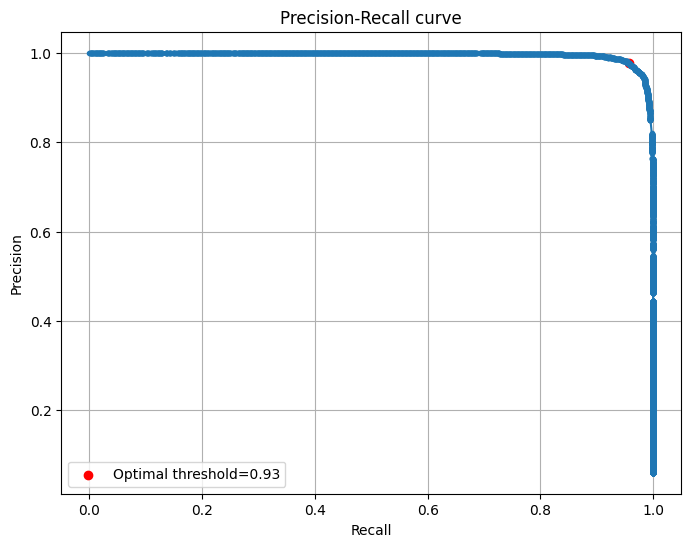

In [145]:
thres_train, _ = find_optimal_thres(y, y_proba)

### 5.2.3. Predictions calibration

In [146]:
calibrated_model = CalibratedClassifierCV(estimator=model,
                                          method="isotonic", cv=5)
calibrated_model.fit(X, y)

proba_cal_val = calibrated_model.predict_proba(X_eval)[:,1]

In [147]:
# ejemplo de costes
C_FN = 1000  # coste de dejar pasar un fraude
C_FP = 50    # coste de investigar un inocente

best_cost, best_thr, FN, FP = find_cost_optimal_threshold(y_eval, proba_cal_val, C_FN, C_FP)
print(f"Umbral coste-óptimo: {best_thr:.3f} (Coste esperado: {best_cost}, FN={FN}, FP={FP})")


Umbral coste-óptimo: 0.101 (Coste esperado: 715700, FN=666, FP=994)


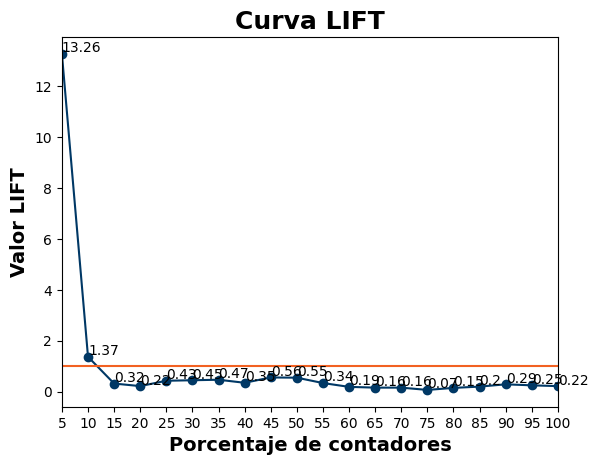

In [148]:
def plot_lift(y_true, proba, bins=20):
    df = pd.DataFrame({"y": y_true, "proba": proba})
    df = df.sort_values("proba", ascending=False).reset_index(drop=True)
    df["bucket"] = pd.qcut(df.index, bins, labels=False)

    lift_table = df.groupby("bucket").agg(
        n=("y","size"),
        frauds=("y","sum"),
        avg_score=("proba","mean")
    ).reset_index()

    lift_table["fraud_rate"] = lift_table["frauds"] / lift_table["n"]
    global_rate = df["y"].mean()
    lift_table["lift"] = lift_table["fraud_rate"] / global_rate
    lift_table["cum_frauds"] = lift_table["frauds"].cumsum()
    lift_table["cum_frauds_pct"] = lift_table["cum_frauds"] / df["y"].sum()

    plt.figure(figsize=(8,6))
    plt.plot(np.linspace(0,100,bins), lift_table["cum_frauds_pct"]*100, marker='o')
    plt.xlabel("% población (ordenada por score)")
    plt.ylabel("% fraudes capturados (acumulado)")
    plt.title("Curva Lift acumulada (modelo supervisado)")
    plt.grid(True)
    plt.show()

    return lift_table

lift_table = lift_chart_plot(y_eval, proba_cal_val, num_chunks=20)


In [149]:
y_pred = (y_proba >= thres_train).astype(int)

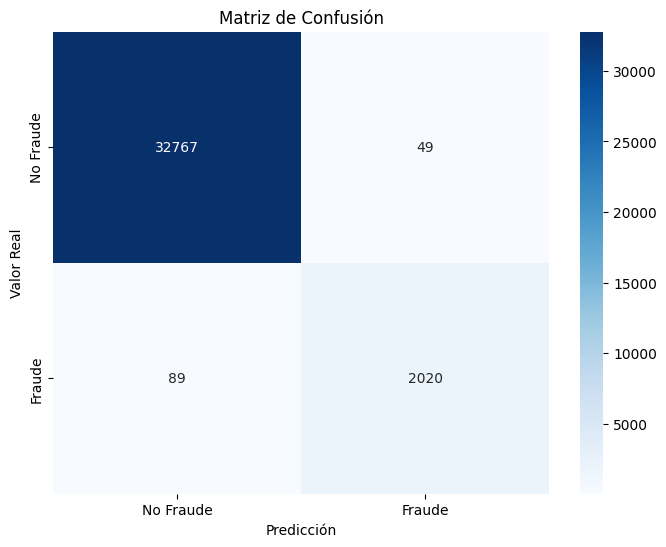


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     32816
         1.0       0.98      0.96      0.97      2109

    accuracy                           1.00     34925
   macro avg       0.99      0.98      0.98     34925
weighted avg       1.00      1.00      1.00     34925



In [150]:
cm = confusion_matrix(y, y_pred)
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))

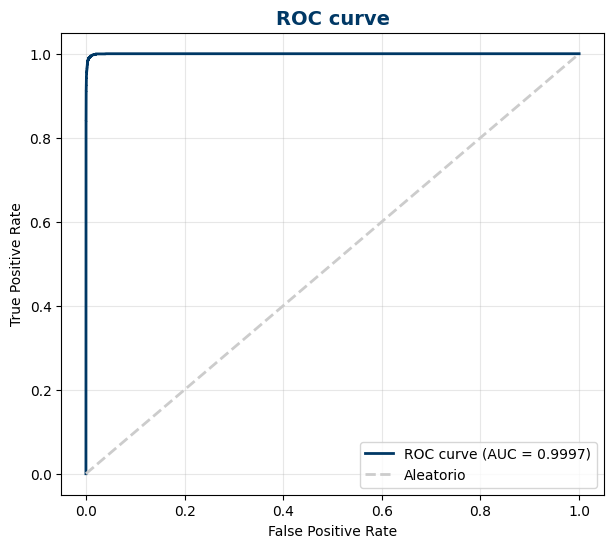

ROC AUC Score: 0.9997


In [151]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Let's see also gain and lift curves

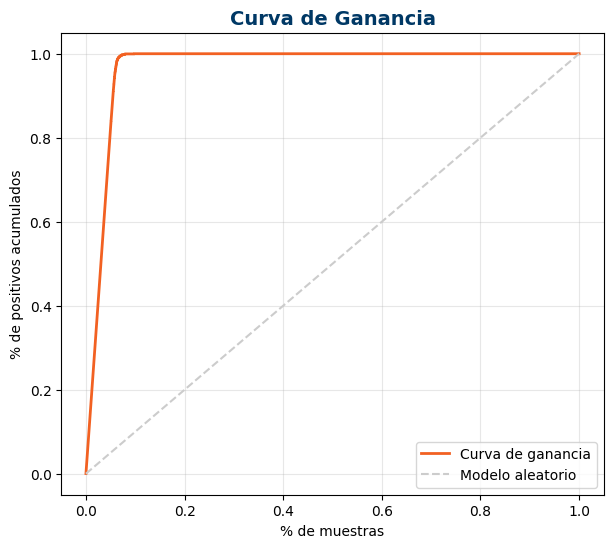

In [152]:
plot_gain(y, y_proba)

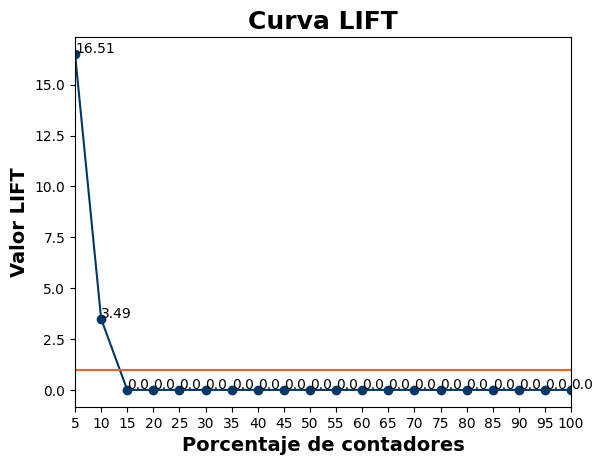

In [153]:
lift_chart_plot(y, y_proba, num_chunks=20)

In [154]:
final_df["target"].value_counts()

target
0.0    32816
1.0     2109
Name: count, dtype: int64

In [155]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [156]:
final_df["pred_proba"] = y_proba

In [157]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [158]:
cuts = [25, 35]  
thresholds = get_probability_thresholds(y, y_proba, cuts)

print("Thresholds:", thresholds)

Thresholds: [0.0032163402562538548, 0.0009658056966437603]


We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [159]:
conditions = [
    final_df["final_scoring"] < thresholds[0],                             
    (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
    final_df["final_scoring"] >= thresholds[1]                             
]

choices = ["Bajo", "Medio", "Alto"]

final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.2.4. Feature importance

In [160]:
importancias = model.feature_importances_
features = X.columns

df_importancia = pd.DataFrame({
    'feature': features,
    'importance': importancias
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

df_importancia.head(10)

,feature,importance
0,consumo_count_anio_anterior,107
1,porcentaje_calidad_datos_semana_actual_correctos,99
2,consumo_count_anio_actual,94
3,porcentaje_calidad_datos_mismo_trimestre_anio_...,76
4,porcentaje_calidad_datos_mes_actual_correctos,75
5,consumo_zero_anio_actual,73
6,coef_variacion_semana_actual,70
7,cnt_eventos_semana_pasada_6_NA,58
8,consumo_min_anio_actual,49
9,consumo_zero_anio_anterior,37


Let's save this data frame into the powerbi folder. We will use then this data to show it in the dashboard

In [161]:
df_importancia.head(10).to_csv(OUTPUT_FEATURE_IMPORTANCE_XGB, sep=";", decimal=",")

## 5.3. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [162]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [163]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
y_pred_eval = model.predict(X_eval[X.columns]) # threshold 0.5

In [164]:
final_df_eval["pred_proba"] = y_proba_eval
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado"]*0.3 + final_df_eval["pred_proba"]*0.7

In [165]:
thresholds_val = get_probability_thresholds(y_eval, final_df_eval["final_scoring"], cuts)

conditions_val = [
    final_df_eval["final_scoring"] < thresholds_val[0],                             
    (final_df_eval["final_scoring"] >= thresholds_val[0]) & (final_df_eval["final_scoring"] < thresholds_val[1]),  
    final_df_eval["final_scoring"] >= thresholds_val[1]                             
]

final_df_eval["categoria_fraude"] = np.select(conditions_val, choices, default="Bajo")

In [166]:
final_df_eval["categoria_fraude"].value_counts()

categoria_fraude
Bajo    27225
Alto     9075
Name: count, dtype: int64

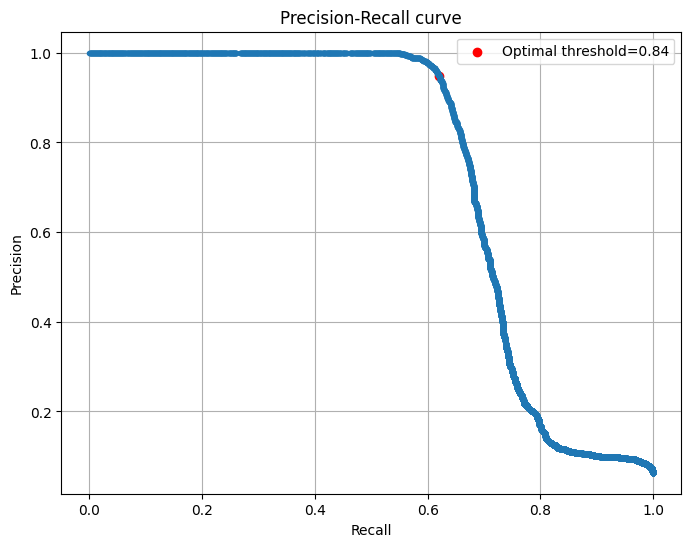

In [167]:
thres_val, _ = find_optimal_thres(y_eval, y_proba_eval)

Let's define the prediction array making use of the extracted threshold

In [168]:
y_pred_eval = (y_proba_eval >= thres_val).astype(int)
y_pred_eval = (y_proba_eval >= thres_train).astype(int)

If we show the confusion matrix:

In [169]:
model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'is_unbalance': True,
 'verbose': -1}

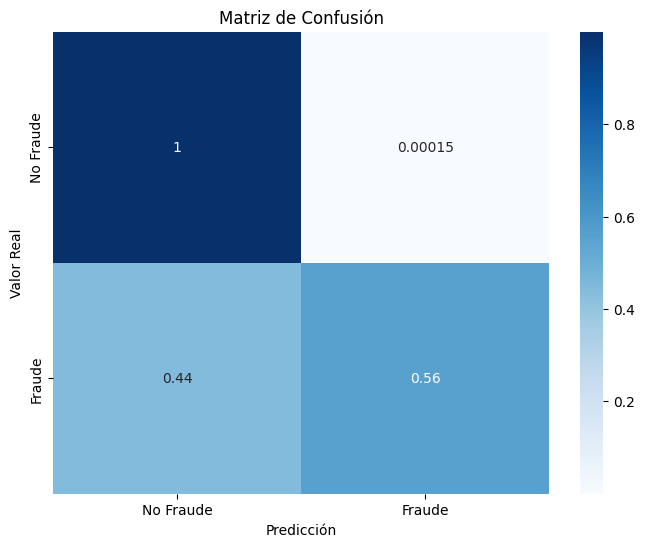


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99     33999
         1.0       1.00      0.56      0.72      2301

    accuracy                           0.97     36300
   macro avg       0.98      0.78      0.85     36300
weighted avg       0.97      0.97      0.97     36300

0.7156780840991367


In [170]:
cm = confusion_matrix(y_eval, y_pred_eval, normalize="true")
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'], )
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_eval, y_pred_eval))

print(f1_score(y_eval, y_pred_eval))

Primeramente pintaremos la curva ROC junto con su valor de AUC

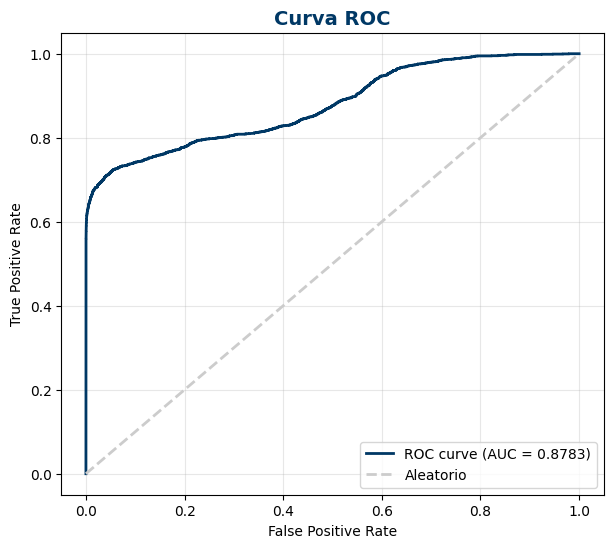

ROC AUC Score: 0.8783


In [171]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

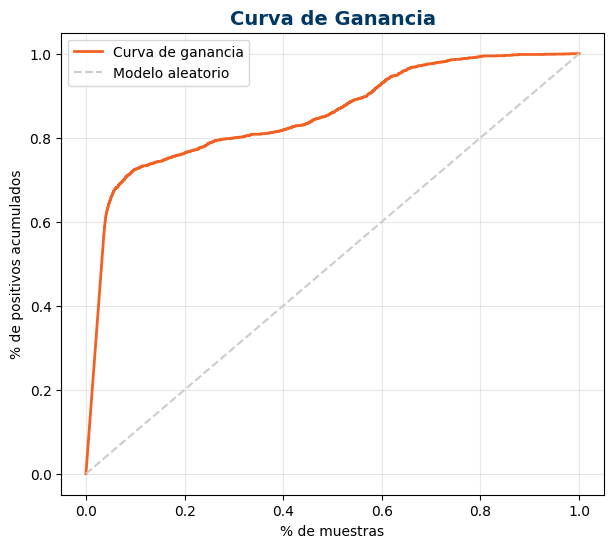

In [172]:
plot_gain(y_eval, y_proba_eval)

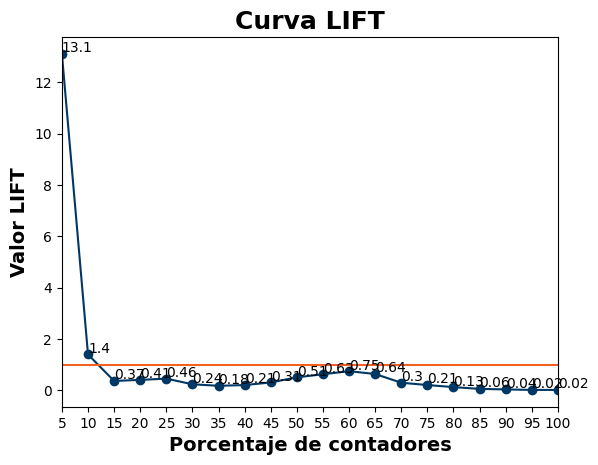

In [173]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=20)

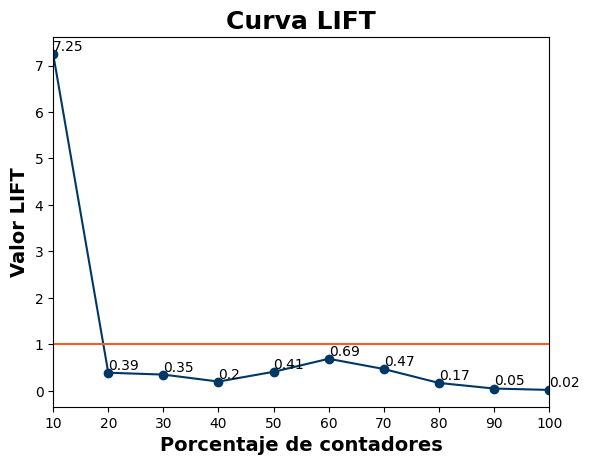

In [174]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=10)

## 5.4. Explainability

Let's make a global shap plot, in order to understand how the model gives predictions

c:\Users\alarrinoar\Desktop\Projects\UFD\.venv\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


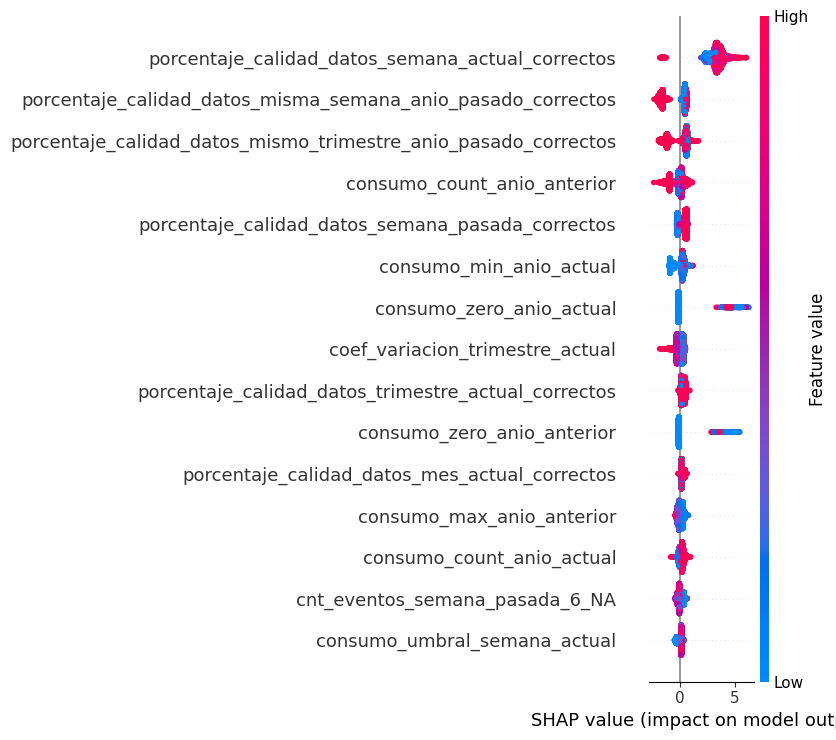

In [175]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_eval)

shap.summary_plot(shap_values, X_eval, max_display=15)

In [176]:
df_shap_eval = final_df_eval[["cups_sgc", "cnt_id"]].join(X_eval, how="right")
df_shap_eval.head(5)

,cups_sgc,cnt_id,consumo_zero_anio_actual,consumo_zero_trimestre_actual,consumo_zero_trimestre_pasado,consumo_zero_trimestre_anio_pasado,porcentaje_calidad_datos_mes_actual_correctos,consumo_zero_anio_anterior,consumo_zero_semana_actual,consumo_zero_mes_actual,...,consumo_umbral_semana_anio_pasado,consumo_suma_trimestre_anio_pasado,consumo_min_mes_anio_pasado,consumo_umbral_anio_actual,cnt_eventos_semana_pasada_6_NA,consumo_min_semana_pasada,consumo_max_mes_pasado,coef_variacion_semana_actual,consumo_max_mes_anio_pasado,cnt_eventos_anio_pasado_1_24
0,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,94.44,0.0,0.0,0.0,...,168.0,260009.0,114.0,8298.0,20.0,78.0,3355.0,100.47,3186.0,1.0
1,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,97.22,0.0,0.0,0.0,...,167.0,1000000.0,130.0,8655.0,14.0,122.0,15333.0,154.88,11038.0,1.0
2,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,98.06,0.0,0.0,0.0,...,0.0,0.0,0.0,2455.0,34.0,204.0,5093.0,74.20,0.0,0.0
3,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,96.94,0.0,0.0,0.0,...,168.0,1000000.0,2091.0,8713.0,56.0,1197.0,3084.0,20.75,8374.0,1.0
4,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,30.97,0.0,0.0,0.0,...,31.0,42346.0,4.0,1071.0,12.0,4.0,1040.0,147.25,1033.0,1.0


In [177]:
# Pasamos shap_values a DataFrame
df_shap_local = pd.DataFrame(shap_values, columns=X_eval.columns)

# Añadimos las predicciones y el identificador
df_local_explain = pd.DataFrame({
    "cups_sgc": df_shap_eval["cups_sgc"], 
    "cnt_id": df_shap_eval["cnt_id"], 
    "prediction": model.predict_proba(X_eval)[:,1]
})

# 3. Pasamos a formato largo (para Power BI)
df_shap_long = df_shap_local.reset_index().melt(
    id_vars="index",
    var_name="feature",
    value_name="shap_value"
)

# 4. Unimos con los identificadores y predicciones
df_explain_final = df_shap_long.merge(
    df_local_explain.reset_index(),
    on="index"
).drop(columns=["index"])

df_explain_final["abs_shap_value"] = df_explain_final["shap_value"].abs()
# Esto lo exportas a CSV y lo cargas en Power BI
df_explain_final.to_csv("../powerbi/shap_local_explain_xgb.csv", index=False, decimal=",", sep=";")


## 5.7. Dashboard data extraction

Necesitamos extraer ciertos ficheros para la construcción del dashboard en powerbi

In [178]:
columnas_considerar_preds = ["cups_sgc", "cnt_id", "fraude_score_no_supervisado", 
                             "pred_proba", "final_scoring", "categoria_fraude"]

In [179]:
grid_contadores_control = pd.read_csv(INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL)
grid_contadores_fraude = pd.read_csv(INPUT_GRID_CONTADORES_FRAUDE_PATH_ABRIL)

df_grid_contadores = pd.concat([grid_contadores_control, grid_contadores_fraude])

# Convertir a numérico (si hay valores raros, los pone como NaN)
df_grid_contadores["coord_utm_x_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_x_bdi"], errors="coerce")
df_grid_contadores["coord_utm_y_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_y_bdi"], errors="coerce")

# Crear transformador (UTM zona 30N -> WGS84)
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

# Transformar coordenadas (saltará NaN si alguna fila no tenía valores válidos)
df_grid_contadores["longitud"], df_grid_contadores["latitud"] = transformer.transform(
    df_grid_contadores["coord_utm_x_bdi"].values,
    df_grid_contadores["coord_utm_y_bdi"].values
)

# df_grid_contadores.to_csv("coordenadas_contadores_lat_long.csv", index=False, decimal=",", sep=";")

NameError: name 'INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL' is not defined

In [ ]:
df_grid_contadores

,cups_sgc,cnt_id,fases_sgc,coord_utm_x_bdi,coord_utm_y_bdi,cod_postal_sgc,municipio_sgc,provincia_sgc,ccaa_sgc,longitud,latitud
0,ES0022000007510765PX1P,SOG0040091624,MONOFÁSICO,480145.0,4310079.0,13240,LA SOLANA,CIUDAD REAL,CASTILLA LA MANCHA,-3.229099,38.939421
1,ES0022000009056979YA1P,ZIV0042574489,MONOFÁSICO,447577.0,4482919.0,28055,MADRID,MADRID,MADRID,-3.618633,40.495320
2,ES0022000007875119WK1P,ZIV0048360380,MONOFÁSICO,500788.0,4710977.0,15960,RIBEIRA,A CORUÑA,GALICIA,-2.990402,42.551188
3,ES0022000007015524GM1P,ZIV0044281450,MONOFÁSICO,567463.0,4818457.0,15572,NARON,A CORUÑA,GALICIA,-2.165301,43.516003
4,ES0022000004466494JL1P,SOG0940090780,MONOFÁSICO,512077.0,4639402.0,36789,A GUARDA,PONTEVEDRA,GALICIA,-2.854387,41.906470
...,...,...,...,...,...,...,...,...,...,...,...
2313,ES0022000004089719PF1P,ZIV0035129747,MONOFÁSICO,547901.0,4800948.0,15005,A CORUÑA,A CORUÑA,GALICIA,-2.408857,43.359864
2314,ES0022000006366104NJ1P,SAG0195829801,MONOFÁSICO,447380.0,4474822.0,28037,MADRID,MADRID,MADRID,-3.620287,40.422365
2315,ES0022000005466282NC1P,ZIV0044156878,MONOFÁSICO,513456.0,4461803.0,19117,ALBALATE DE ZORITA,GUADALAJARA,CASTILLA LA MANCHA,-2.841651,40.306629
2316,ES0022000007909380CN1P,SAG0125276188,MONOFÁSICO,455480.0,4475345.0,28830,SAN FERNANDO DE HENARES,MADRID,MADRID,-3.524844,40.427549


In [ ]:
(
    final_df_eval[columnas_considerar_preds]
    .merge(df_grid_contadores, how="left", on=["cups_sgc", "cnt_id"])
    .to_csv("powerbi/predicciones_cups.csv", index=False, sep=";", decimal=",")
)

In [ ]:
def lift_at_percentile(y_true, y_proba, percentile=0.1):
    """
    Calcula el Lift en el top X% (percentile en [0,1]).
    """
    n = int(len(y_proba) * percentile)
    # Ordenar por probabilidad descendente
    idx = np.argsort(y_proba)[::-1]
    y_sorted = np.array(y_true)[idx]
    
    # Positivos en el top %
    top_positives = y_sorted[:n].sum()
    total_positives = y_sorted.sum()
    
    perc_total = top_positives / total_positives
    perc_samples = n / len(y_true)
    
    lift = perc_total / perc_samples
    return lift, perc_total

def compute_metrics(y_true, y_proba, dataset_name="test"):
    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    ks = ks_stat(y_true, y_proba)
    lift10, capture10 = lift_at_percentile(y_true, y_proba, 0.1)
    lift20, capture20 = lift_at_percentile(y_true, y_proba, 0.2)

    return {
        "dataset": dataset_name,
        "auc": round(auc, 3),
        "gini": round(gini, 3),
        "ks": round(ks, 3),
        "lift_at_10": lift10,
        "capture_rate_10": capture10,
        "lift_at_20": lift20,
        "capture_rate_20": capture20
    }

# =====================
# Calcular métricas train y test
# =====================
metrics_train = compute_metrics(y, y_proba, dataset_name="train")
metrics_test = compute_metrics(y_eval, y_proba_eval, dataset_name="test")

model_metrics = pd.DataFrame([metrics_train, metrics_test])

model_metrics.to_csv("powerbi/model_metrics.csv", index=False, sep=";", decimal=",")

In [ ]:
model_metrics

,dataset,auc,gini,ks,lift_at_10,capture_rate_10,lift_at_20,capture_rate_20
0,train,0.997,0.994,0.960,9.835453,0.983404,4.964438,0.992888
1,test,0.917,0.833,0.718,7.696654,0.769665,4.235115,0.847023


In [ ]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba)

roc_data = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})
roc_data.to_csv("powerbi/roc_curve.csv", index=False, sep=";", decimal=",")

ValueError: Found input variables with inconsistent numbers of samples: [36300, 34925]

In [ ]:
data = list(zip(y_eval, y_proba_eval))
data = sorted(data, key=lambda x: x[1], reverse=True)
y_sorted = np.array([d[0] for d in data])

cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

gain_data = pd.DataFrame({
    "perc_samples": perc_samples,
    "cum_gains": cum_gains
})
gain_data.to_csv("powerbi/gain_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
def compute_lift(y_true, y_proba, bins=20):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift_values, percentiles = [], []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift = group_rate / total_rate
        lift_values.append(lift)
        percentiles.append(100 - (i+1)*(100//bins))  # de 100 a 0

    return pd.DataFrame({
        "percentil": percentiles,
        "lift": lift_values
    })

lift_data = compute_lift(y_test, y_proba, bins=20)
lift_data.to_csv("powerbi/lift_curve.csv", index=False, sep=";", decimal=",")